# 量化的日常是什么？

前面八章，我们从零搭建了一个完整的量化策略。
这一章，我们回头看看——这些决策背后，藏着量化交易员每天都在做的核心工作：**因子研究**。

## Step 1: 从直觉到因子

回顾一下前面课程中的投资决策：

| 章节 | 决策 | 用了什么数据 | 因子名称 | 因子类别 |
|------|------|-------------|---------|---------|
| Q2 选什么 | 选哪个国家的市场 | GDP 总量/增速 | GDP 因子 | 宏观因子 |
| Q3 买多少 | 涨的多买、跌的不买 | 风险调整动量 | 动量因子 | 动量因子 |

你可能没意识到，Q2 和 Q3 里你已经在用因子了。因子就是你做投资决策时参考的那个数据——GDP 高的国家更值得投、涨得好的多买一点。量化研究的日常工作，就是不断寻找和评估这些因子。

### 怎么评估一个因子好不好？

一个因子好不好，最直接的检验方式是：**它的打分排名，和实际收益排名有多像？**

这就是 **IC（Information Coefficient，信息系数）** 的核心思想。

**计算方法：**

$$IC_t = \text{Spearman相关系数}(\text{因子值排名}, \text{下一期收益率排名})$$

Spearman 相关系数就是比较两个排名的相似程度，范围从 -1 到 +1：
- +1 表示因子排名和收益排名完全一致（完美预测）
- -1 表示完全相反
- 0 表示毫无关系

**IC 均值：** 多期 IC 的平均值，反映因子是否长期有效。
- 绝对值 > 0.03：有一定参考价值
- 绝对值 > 0.05：算不错的因子
- 绝对值 > 0.1：非常强的因子

**ICIR（IC 信息比率）：** IC 均值 / IC 标准差，衡量 IC 的稳定性。类似夏普比率的思路——不仅要均值高，还要稳定。

> 还有其他评估方法（因子收益率、分组回测等），但本课程主要用 IC，因为它最直观。

In [94]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from oxq.data.loaders import YFinanceDownloader
from oxq.data.market import LocalMarketDataProvider
from oxq.data.factors import WorldBankFetcher, FactorDownloader, read_factor
from oxq.indicators.momentum import Momentum
from oxq.indicators.rolling_volatility import RollingVolatility

# 中文显示设置
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'STHeiti', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

%matplotlib inline
print("库加载完成 ✓")

库加载完成 ✓


In [95]:
# 下载 GDP 数据
countries = ["USA", "CHN", "JPN", "DEU", "GBR", "FRA", "IND", "BRA", "CAN", "KOR"]

fetcher = WorldBankFetcher()
dl = FactorDownloader(fetcher, sub="macro")
dl.download("gdp", start="2010", end="2024", countries=countries)

gdp_df = read_factor("gdp", countries=countries, start_year=2010, end_year=2024)
print(f"GDP 数据形状: {gdp_df.shape}")
print()
# 显示为万亿美元，更易读
display_df = (gdp_df / 1e12).round(2)
display_df.columns.name = "国家"
display_df.index.name = "年份"
print("各国 GDP（万亿美元）:")
print(display_df)

GDP 数据形状: (15, 10)

各国 GDP（万亿美元）:
国家      USA    CHN   JPN   DEU   GBR   FRA   IND   BRA   CAN   KOR
年份                                                                
2010  15.05   6.19  5.76  3.47  2.50  2.65  1.68  2.21  1.62  1.19
2011  15.60   7.67  6.23  3.82  2.68  2.87  1.82  2.62  1.79  1.31
2012  16.25   8.67  6.27  3.60  2.72  2.68  1.83  2.47  1.83  1.34
2013  16.84   9.74  5.21  3.81  2.80  2.82  1.86  2.47  1.85  1.43
2014  17.55  10.67  4.90  3.96  3.09  2.86  2.04  2.46  1.81  1.56
2015  18.21  11.28  4.44  3.43  2.95  2.44  2.10  1.80  1.56  1.54
2016  18.70  11.46  5.00  3.54  2.71  2.47  2.29  1.80  1.53  1.58
2017  19.48  12.54  4.93  3.77  2.70  2.59  2.65  2.06  1.65  1.71
2018  20.53  14.15  5.04  4.06  2.90  2.78  2.70  1.92  1.73  1.82
2019  21.38  14.56  5.12  3.96  2.88  2.72  2.84  1.87  1.74  1.75
2020  21.06  15.00  5.05  3.94  2.72  2.65  2.67  1.48  1.66  1.74
2021  23.32  18.20  5.04  4.36  3.19  2.97  3.17  1.67  2.02  1.94
2022  25.60  18.32  4.26  4.

In [96]:
# 下载 ETF 数据
COUNTRY_ETF = {
    "USA": "QQQ", "CHN": "FXI", "JPN": "EWJ", "DEU": "EWG",
    "GBR": "EWU", "FRA": "EWQ", "IND": "INDA", "BRA": "EWZ",
    "CAN": "EWC", "KOR": "EWY",
}

downloader = YFinanceDownloader()
provider = LocalMarketDataProvider()

for country, ticker in COUNTRY_ETF.items():
    try:
        downloader.download(ticker, "2011-01-01", "2026-12-31")
    except Exception as e:
        print(f"  [注意] {ticker} 下载: {e}")

print(f"{'国家':<6} {'ETF':<6} {'数据条数':>8} {'起始日期':<12} {'结束日期':<12}")
print("-" * 50)
etf_data = {}
for country, ticker in COUNTRY_ETF.items():
    df = provider.get_bars(ticker, "2011-01-01", "2026-12-31")
    etf_data[country] = df
    print(f"{country:<6} {ticker:<6} {len(df):>8} {str(df.index[0].date()):<12} {str(df.index[-1].date()):<12}")

国家     ETF        数据条数 起始日期         结束日期        
--------------------------------------------------
USA    QQQ        3830 2011-01-03   2026-03-26  
CHN    FXI        3830 2011-01-03   2026-03-26  
JPN    EWJ        3830 2011-01-03   2026-03-26  
DEU    EWG        3830 2011-01-03   2026-03-26  
GBR    EWU        3830 2011-01-03   2026-03-26  
FRA    EWQ        3830 2011-01-03   2026-03-26  
IND    INDA       3556 2012-02-03   2026-03-26  
BRA    EWZ        3830 2011-01-03   2026-03-26  
CAN    EWC        3830 2011-01-03   2026-03-26  
KOR    EWY        3830 2011-01-03   2026-03-26  


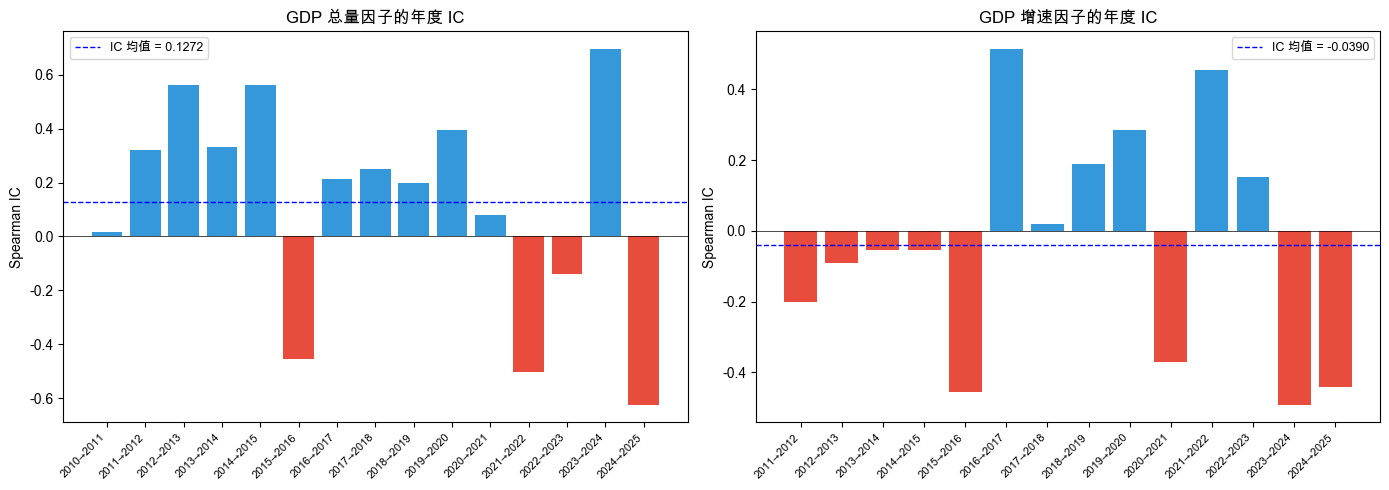

GDP 总量因子: IC 均值 = 0.1272, ICIR = 0.3158
GDP 增速因子: IC 均值 = -0.0390, ICIR = -0.1177


In [97]:
# 计算两个 GDP 因子的年度 IC：GDP 总量 vs GDP 增速
# GDP 总量因子：当年 GDP 排名 → 预测下一年 ETF 收益排名
# GDP 增速因子：当年 GDP 增速排名 → 预测下一年 ETF 收益排名

# 1. 计算每个国家 ETF 的年度收益率（年末/年初 - 1）
annual_returns = {}
for country, df in etf_data.items():
    for year in range(2011, 2027):
        year_data = df[df.index.year == year]
        if len(year_data) < 20:
            continue
        ret = (year_data["close"].iloc[-1] / year_data["close"].iloc[0]) - 1
        if year not in annual_returns:
            annual_returns[year] = {}
        annual_returns[year][country] = ret

# 2. 计算 GDP 增速：GDP_year / GDP_year-1 - 1
gdp_growth = gdp_df.pct_change()

# 3. 计算两个因子的 IC
ic_level = {}   # GDP 总量因子
ic_growth = {}  # GDP 增速因子

for year in sorted(gdp_df.index):
    next_year = year + 1
    if next_year not in annual_returns:
        continue

    ret_row = annual_returns[next_year]

    # GDP 总量因子 IC
    gdp_row = gdp_df.loc[year]
    common = [c for c in countries if pd.notna(gdp_row.get(c)) and c in ret_row]
    if len(common) >= 4:
        gdp_vals = [gdp_row[c] for c in common]
        ret_vals = [ret_row[c] for c in common]
        corr, _ = stats.spearmanr(gdp_vals, ret_vals)
        ic_level[f"{year}→{next_year}"] = corr

    # GDP 增速因子 IC
    if year in gdp_growth.index:
        growth_row = gdp_growth.loc[year]
        common_g = [c for c in countries if pd.notna(growth_row.get(c)) and c in ret_row]
        if len(common_g) >= 4:
            growth_vals = [growth_row[c] for c in common_g]
            ret_vals_g = [ret_row[c] for c in common_g]
            corr_g, _ = stats.spearmanr(growth_vals, ret_vals_g)
            ic_growth[f"{year}→{next_year}"] = corr_g

# 4. 画两张 IC 柱状图并排对比
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ic_dict, title in [
    (axes[0], ic_level, "GDP 总量因子"),
    (axes[1], ic_growth, "GDP 增速因子"),
]:
    ic_values = list(ic_dict.values())
    ic_labels = list(ic_dict.keys())
    ic_mean = np.mean(ic_values)
    ic_std = np.std(ic_values, ddof=1)

    colors_ic = ['#3498db' if v > 0 else '#e74c3c' for v in ic_values]
    ax.bar(range(len(ic_dict)), ic_values, color=colors_ic)
    ax.set_xticks(range(len(ic_dict)))
    ax.set_xticklabels(ic_labels, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Spearman IC")
    ax.set_title(f"{title}的年度 IC")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.axhline(ic_mean, color="blue", linestyle="--", linewidth=1,
               label=f"IC 均值 = {ic_mean:.4f}")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# 5. 打印对比
for name, ic_dict in [("GDP 总量因子", ic_level), ("GDP 增速因子", ic_growth)]:
    vals = list(ic_dict.values())
    m = np.mean(vals)
    s = np.std(vals, ddof=1)
    icir = m / s if s > 0 else 0
    print(f"{name}: IC 均值 = {m:.4f}, ICIR = {icir:.4f}")

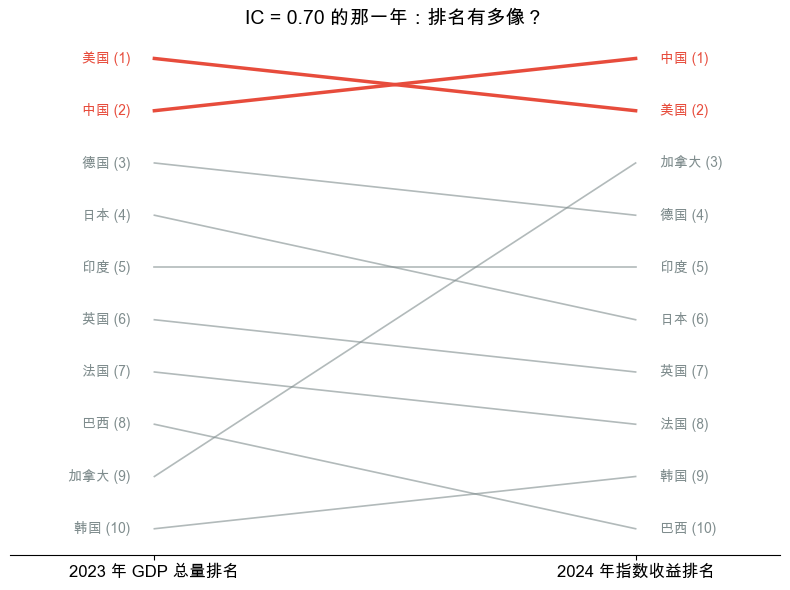


2023→2024：GDP 总量排名和下一年指数收益排名的 Spearman 相关系数 = 0.70
排名越接近（线越平），IC 越高；排名交叉越多（线越乱），IC 越低。


In [98]:
# IC 最高那一年长什么样？——排名对比图
# 选 GDP 总量因子 IC 最大的那一年，展示因子排名 vs 收益排名

best_year_label = max(ic_level, key=ic_level.get)
best_ic = ic_level[best_year_label]
best_gdp_year = int(best_year_label.split("→")[0])
best_ret_year = int(best_year_label.split("→")[1])

# 取该年 GDP 和下一年收益
gdp_row = gdp_df.loc[best_gdp_year]
ret_row = annual_returns[best_ret_year]
common = [c for c in countries if pd.notna(gdp_row.get(c)) and c in ret_row]

# 构建排名
gdp_rank = pd.Series({c: gdp_row[c] for c in common}).rank(ascending=False).astype(int)
ret_rank = pd.Series({c: ret_row[c] for c in common}).rank(ascending=False).astype(int)

# 中文名映射
cn_names = {
    "USA": "美国", "CHN": "中国", "JPN": "日本", "DEU": "德国", "GBR": "英国",
    "FRA": "法国", "IND": "印度", "BRA": "巴西", "CAN": "加拿大", "KOR": "韩国",
}

# 画排名对比图：左列 GDP 排名，右列收益排名，连线
fig, ax = plt.subplots(figsize=(8, 6))

n = len(common)
sorted_countries = gdp_rank.sort_values().index.tolist()

for c in sorted_countries:
    g_rank = gdp_rank[c]
    r_rank = ret_rank[c]
    color = '#e74c3c' if c in ['USA', 'CHN'] else '#7f8c8d'
    lw = 2.5 if c in ['USA', 'CHN'] else 1.2
    alpha = 1.0 if c in ['USA', 'CHN'] else 0.6
    ax.plot([0, 1], [g_rank, r_rank], color=color, linewidth=lw, alpha=alpha)
    ax.text(-0.05, g_rank, f"{cn_names.get(c, c)} ({g_rank})", ha='right', va='center',
            fontsize=10, fontweight='bold' if c in ['USA', 'CHN'] else 'normal',
            color=color)
    ax.text(1.05, r_rank, f"{cn_names.get(c, c)} ({r_rank})", ha='left', va='center',
            fontsize=10, fontweight='bold' if c in ['USA', 'CHN'] else 'normal',
            color=color)

ax.set_xlim(-0.3, 1.3)
ax.set_ylim(n + 0.5, 0.5)
ax.set_xticks([0, 1])
ax.set_xticklabels([f"{best_gdp_year} 年 GDP 总量排名", f"{best_ret_year} 年指数收益排名"],
                    fontsize=12)
ax.set_yticks([])
ax.set_title(f"IC = {best_ic:.2f} 的那一年：排名有多像？", fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tight_layout()
plt.show()

print(f"\n{best_year_label}：GDP 总量排名和下一年指数收益排名的 Spearman 相关系数 = {best_ic:.2f}")
print("排名越接近（线越平），IC 越高；排名交叉越多（线越乱），IC 越低。")

### GDP 因子分析

我们对比了两个 GDP 因子：

- **GDP 总量因子**：用一个国家的 GDP 绝对值排名来预测下一年 ETF 收益排名
- **GDP 增速因子**：用一个国家的 GDP 增长率排名来预测下一年 ETF 收益排名

结果很有意思：GDP 总量因子的 IC 均值为正，说明 GDP 越大的国家，下一年股市表现确实有略好的倾向。虽然很弱、不稳定，但方向是对的。这就呼应了 Q2 的选择逻辑——我们根据 GDP 总量挑选了最大的两个经济体（中国和美国），用沪深 300 和纳斯达克来构建候选池，背后是有数据支撑的。

而 GDP 增速因子的 IC 更差，说明"增长快"并不能预测"股市涨得好"——经济增速和股市回报的关系比直觉想的要弱得多。

GDP 因子的局限也很明显：年度数据、10 个国家、十几年样本，IC 估计噪音很大。但这正好说明了 IC 的价值——不是拍脑袋觉得"有道理"就行，要用数据验证。

### 因子的分类

| 因子类别 | 含义（一句话） | 常见例子 | 数据来源 |
|---------|--------------|---------|---------|
| 价值 | 便不便宜 | 市盈率、市净率 | 财报数据 |
| 动量 | 涨跌趋势 | N 日收益率、风险调整动量 | 价格数据 |
| 质量 | 公司好不好 | 利润率、负债率 | 财报数据 |
| 波动率 | 稳不稳 | 历史波动率 | 价格数据 |
| 宏观 | 大环境 | GDP、利率 | 经济数据 |
| 另类 | 非传统信息 | 新闻情绪、卫星图像 | 另类数据 |

前面课程里我们用过宏观因子（GDP）和动量因子（风险调整动量）。接下来我们重点研究动量因子——因为它用的是每天都有的价格数据，样本量大、更新快，最适合日常研究。

GDP 因子受限于年度频率和小样本，IC 很不稳定。接下来，我们用日频价格数据、更多标的来评估动量因子——这才是量化研究员的日常节奏。

## Step 2: 动量因子——涨得好的会继续涨吗？

In [99]:
# 构建标的池：22 个国家/地区 ETF + 3 个大宗商品 ETF = 25 只
ALL_ASSETS = {
    # 原有 10 国
    "USA":    {"ticker": "QQQ",  "name": "美国纳斯达克"},
    "CHN":    {"ticker": "FXI",  "name": "中国沪深300"},
    "JPN":    {"ticker": "EWJ",  "name": "日本"},
    "DEU":    {"ticker": "EWG",  "name": "德国"},
    "GBR":    {"ticker": "EWU",  "name": "英国"},
    "FRA":    {"ticker": "EWQ",  "name": "法国"},
    "IND":    {"ticker": "INDA", "name": "印度"},
    "BRA":    {"ticker": "EWZ",  "name": "巴西"},
    "CAN":    {"ticker": "EWC",  "name": "加拿大"},
    "KOR":    {"ticker": "EWY",  "name": "韩国"},
    # 新增 12 国
    "AUS":    {"ticker": "EWA",  "name": "澳大利亚"},
    "TWN":    {"ticker": "EWT",  "name": "台湾"},
    "MEX":    {"ticker": "EWW",  "name": "墨西哥"},
    "ITA":    {"ticker": "EWI",  "name": "意大利"},
    "ESP":    {"ticker": "EWP",  "name": "西班牙"},
    "SWE":    {"ticker": "EWD",  "name": "瑞典"},
    "NLD":    {"ticker": "EWN",  "name": "荷兰"},
    "THA":    {"ticker": "THD",  "name": "泰国"},
    "MYS":    {"ticker": "EWM",  "name": "马来西亚"},
    "ZAF":    {"ticker": "EZA",  "name": "南非"},
    "ISR":    {"ticker": "EIS",  "name": "以色列"},
    "SGP":    {"ticker": "EWS",  "name": "新加坡"},
    # 大宗商品
    "GOLD":   {"ticker": "GLD",  "name": "黄金"},
    "OIL":    {"ticker": "USO",  "name": "原油"},
    "SILVER": {"ticker": "SLV",  "name": "白银"},
}

START, END = "2015-01-01", "2025-12-31"

# 下载所有 ETF 数据
for label, info in ALL_ASSETS.items():
    try:
        downloader.download(info["ticker"], START, END)
    except Exception as e:
        print(f"  [注意] {info['ticker']}: {e}")

# 读取数据并打印覆盖表
all_data = {}
print(f"{'代号':<8} {'Ticker':<8} {'中文名':<12} {'起始日期':<12} {'结束日期':<12} {'交易天数':>8}")
print("-" * 68)
for label, info in ALL_ASSETS.items():
    df = provider.get_bars(info["ticker"], START, END)
    all_data[label] = df
    print(f"{label:<8} {info['ticker']:<8} {info['name']:<12} "
          f"{str(df.index[0].date()):<12} {str(df.index[-1].date()):<12} {len(df):>8}")

print(f"\n共 {len(all_data)} 只标的加载成功")

代号       Ticker   中文名          起始日期         结束日期             交易天数
--------------------------------------------------------------------
USA      QQQ      美国纳斯达克       2015-01-02   2025-12-30       2765
CHN      FXI      中国沪深300      2015-01-02   2025-12-30       2765
JPN      EWJ      日本           2015-01-02   2025-12-30       2765
DEU      EWG      德国           2015-01-02   2025-12-30       2765
GBR      EWU      英国           2015-01-02   2025-12-30       2765
FRA      EWQ      法国           2015-01-02   2025-12-30       2765
IND      INDA     印度           2015-01-02   2025-12-30       2765
BRA      EWZ      巴西           2015-01-02   2025-12-30       2765
CAN      EWC      加拿大          2015-01-02   2025-12-30       2765
KOR      EWY      韩国           2015-01-02   2025-12-30       2765
AUS      EWA      澳大利亚         2015-01-02   2025-12-30       2765
TWN      EWT      台湾           2015-01-02   2025-12-30       2765
MEX      EWW      墨西哥          2015-01-02   2025-12-30       2765
ITA    

In [100]:
# 计算两个动量因子 + 三个前向收益窗口
mom_calc = Momentum()
vol_calc = RollingVolatility()

mom_dict = {}   # 20日动量
ram_dict = {}   # 风险调整动量（RAM = 动量 / 波动率）
vol_dict = {}   # 波动率（Step 3 复用）
fwd_dict = {}   # {horizon: {label: Series}}

HORIZONS = [10, 20, 40]  # 前向收益窗口（交易日）

for label, df in all_data.items():
    mom = mom_calc.compute(df, column="close", period=20)
    vol = vol_calc.compute(df, column="close", period=20)
    ram = mom / vol
    mom_dict[label] = mom
    ram_dict[label] = ram
    vol_dict[label] = vol

    for h in HORIZONS:
        if h not in fwd_dict:
            fwd_dict[h] = {}
        # 前向 h 个交易日的收益率（shift(-h) 确保用未来数据）
        fwd_dict[h][label] = df["close"].pct_change(h).shift(-h)

# 构建横截面因子矩阵
mom_df = pd.DataFrame(mom_dict)
ram_df = pd.DataFrame(ram_dict)
vol_df = pd.DataFrame(vol_dict)
fwd_dfs = {h: pd.DataFrame(fwd_dict[h]) for h in HORIZONS}

print(f"动量因子矩阵形状: {mom_df.shape}")
print(f"RAM 因子矩阵形状: {ram_df.shape}")
print(f"前向收益窗口: {HORIZONS} 交易日")
print(f"\n动量因子矩阵示例（跳过前 20 行 NaN）:")
print(mom_df.dropna().head())

动量因子矩阵形状: (2765, 25)
RAM 因子矩阵形状: (2765, 25)
前向收益窗口: [10, 20, 40] 交易日

动量因子矩阵示例（跳过前 20 行 NaN）:
                 USA       CHN       JPN       DEU       GBR       FRA  \
date                                                                     
2015-02-02 -0.000468  0.000311  0.001531  0.002485  0.000943  0.001605   
2015-02-03  0.000749  0.001494  0.002025  0.005207  0.003440  0.004642   
2015-02-04  0.001380  0.002531  0.003098  0.004588  0.003560  0.004261   
2015-02-05  0.001170  0.001069  0.002800  0.004930  0.003878  0.004821   
2015-02-06 -0.000082 -0.000473  0.001747  0.002709  0.002457  0.002752   

                 IND       BRA       CAN       KOR  ...       SWE       NLD  \
date                                                ...                       
2015-02-02  0.003770 -0.000928 -0.002777  0.001680  ...  0.001764  0.000709   
2015-02-03  0.004506  0.002205 -0.000090  0.002676  ...  0.004213  0.003283   
2015-02-04  0.005560  0.000657 -0.000292  0.003097  ...  0.003281  0.00

因子 → 前向窗口                    IC均值    IC标准差     ICIR     IC>0
------------------------------------------------------------
20日动量 → 10日               -0.0263   0.2794  -0.0941   45.7%
20日动量 → 20日               -0.0290   0.2731  -0.1062   45.7%
20日动量 → 40日               -0.0436   0.2794  -0.1560   43.4%
风险调整动量 → 10日              -0.0161   0.2730  -0.0589   46.0%
风险调整动量 → 20日              -0.0193   0.2705  -0.0714   46.4%
风险调整动量 → 40日              -0.0335   0.2770  -0.1208   45.7%


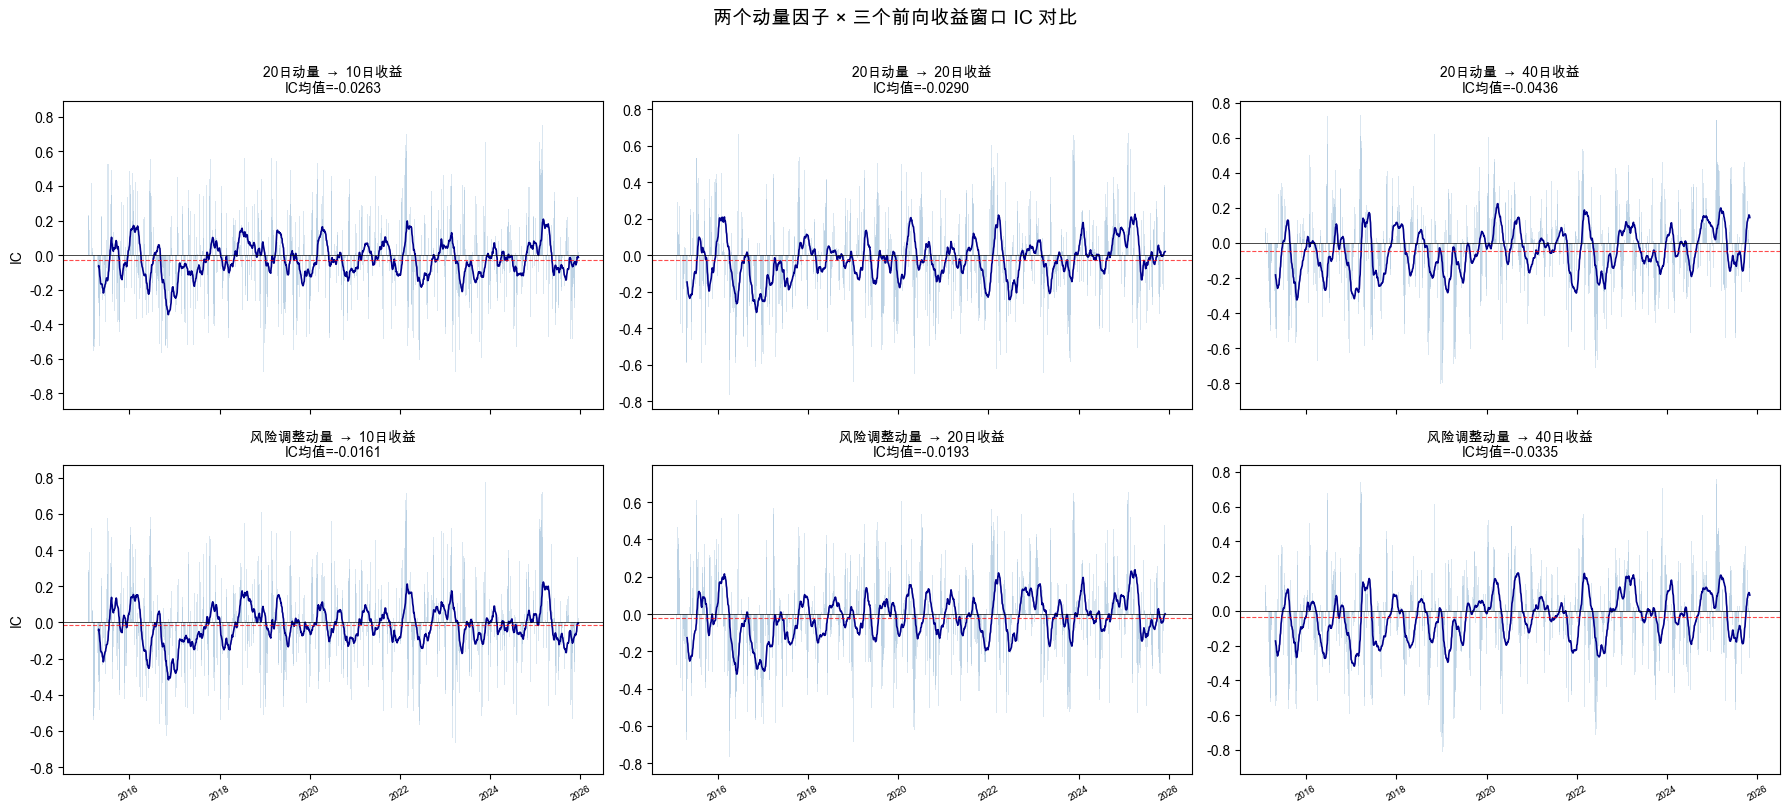

In [101]:
# IC 分析：两个因子 × 三个前向窗口
def compute_ic_series(factor_df, fwd_df, min_assets=5):
    """计算每个交易日的截面 Spearman IC"""
    common_idx = factor_df.index.intersection(fwd_df.index)
    ic_list, ic_dates = [], []
    for dt in common_idx:
        f_row = factor_df.loc[dt].dropna()
        r_row = fwd_df.loc[dt].dropna()
        common = f_row.index.intersection(r_row.index)
        if len(common) < min_assets:
            continue
        corr, _ = stats.spearmanr(f_row[common], r_row[common])
        if not np.isnan(corr):
            ic_list.append(corr)
            ic_dates.append(dt)
    return pd.Series(ic_list, index=ic_dates, name="IC")

# 计算 6 组 IC（2 因子 × 3 窗口）
factors = {"20日动量": mom_df, "风险调整动量": ram_df}
ic_results = {}

for fname, fdf in factors.items():
    for h in HORIZONS:
        key = f"{fname} → {h}日"
        ic_results[key] = compute_ic_series(fdf, fwd_dfs[h])

# 打印 IC 对比表
print(f"{'因子 → 前向窗口':<24} {'IC均值':>8} {'IC标准差':>8} {'ICIR':>8} {'IC>0':>8}")
print("-" * 60)
for key, ic_ts in ic_results.items():
    m, s = ic_ts.mean(), ic_ts.std()
    icir = m / s if s > 0 else 0
    pos = (ic_ts > 0).mean()
    print(f"{key:<24} {m:>8.4f} {s:>8.4f} {icir:>8.4f} {pos:>7.1%}")

# 画 IC 对比图：2 行（因子）× 3 列（窗口）
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True)

for row, (fname, fdf) in enumerate(factors.items()):
    for col, h in enumerate(HORIZONS):
        ax = axes[row, col]
        key = f"{fname} → {h}日"
        ic_ts = ic_results[key]
        m = ic_ts.mean()

        ax.bar(ic_ts.index, ic_ts.values, width=2, alpha=0.2, color="steelblue")
        rolling = ic_ts.rolling(60).mean()
        ax.plot(rolling.index, rolling.values, color="darkblue", linewidth=1.2)
        ax.axhline(0, color="black", linewidth=0.5)
        ax.axhline(m, color="red", linestyle="--", linewidth=0.8, alpha=0.7)
        ax.set_title(f"{fname}  →  {h}日收益\nIC均值={m:.4f}", fontsize=10)
        ax.set_ylabel("IC" if col == 0 else "")
        ax.tick_params(axis='x', rotation=30, labelsize=7)

plt.suptitle("两个动量因子 × 三个前向收益窗口 IC 对比", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# 保留默认 20 日窗口的 IC 时间序列，供 Step 2 后续环境分析使用
ic_ts = ic_results["风险调整动量 → 20日"]
fwd_df = fwd_dfs[20]

按标的自身波动率分组 IC：
因子                   整体IC     高波动组IC     低波动组IC   Spread
--------------------------------------------------------
20日动量             -0.0290    -0.0334    -0.0119   0.0215
风险调整动量            -0.0193    -0.0354    -0.0011   0.0343


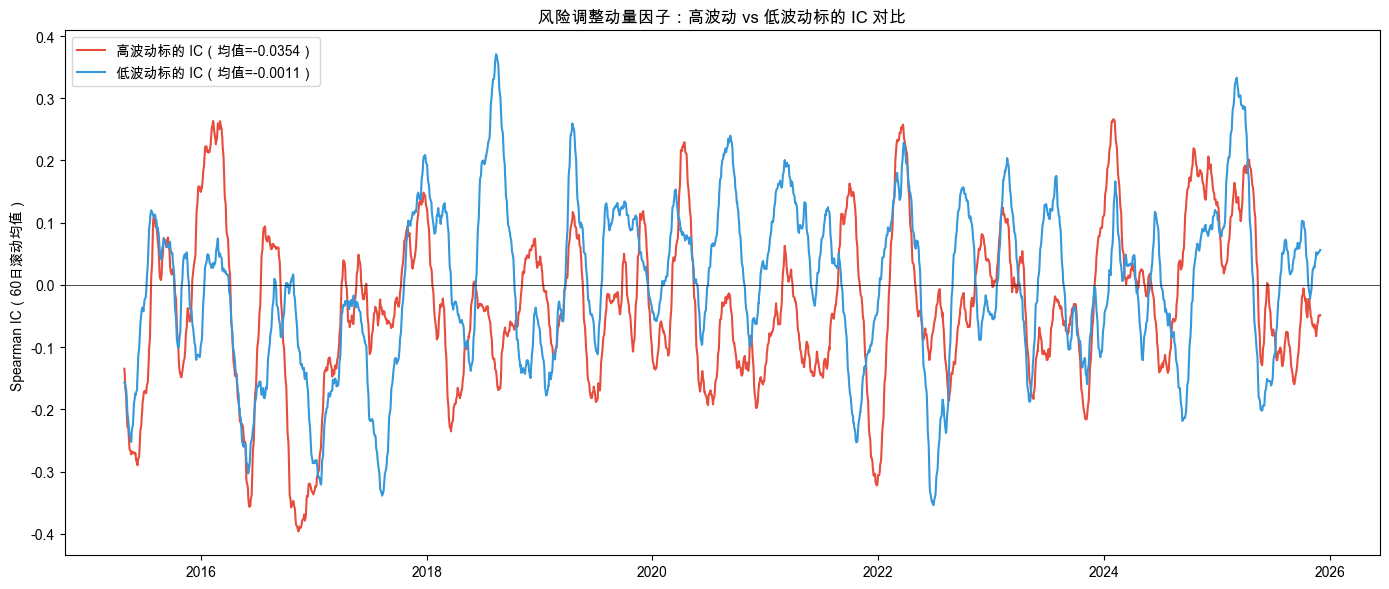

In [102]:
# 分环境 IC 分析：按标的自身波动率分组

# 每个交易日，按各标的当天的 20 日波动率，将标的分为高波动组和低波动组
# 分别在组内计算 Spearman IC，看动量因子在不同波动率的标的上表现有何差异

def compute_grouped_ic(factor_df, fwd_df, vol_df, min_assets=6):
    """按标的自身波动率分组，分别计算组内 IC"""
    common = factor_df.index.intersection(fwd_df.index).intersection(vol_df.index)
    all_ics, high_ics, low_ics = [], [], []
    all_dates, high_dates, low_dates = [], [], []

    for dt in common:
        v = vol_df.loc[dt].dropna()
        f = factor_df.loc[dt].dropna()
        r = fwd_df.loc[dt].dropna()
        c = v.index.intersection(f.index).intersection(r.index)
        if len(c) < 12:
            continue

        # 整体 IC
        corr_all, _ = stats.spearmanr(f[c], r[c])
        if not np.isnan(corr_all):
            all_ics.append(corr_all)
            all_dates.append(dt)

        # 按当天波动率中位数分组
        vol_med = v[c].median()
        hi_assets = c[v[c] > vol_med]
        lo_assets = c[v[c] <= vol_med]

        if len(hi_assets) >= min_assets:
            corr, _ = stats.spearmanr(f[hi_assets], r[hi_assets])
            if not np.isnan(corr):
                high_ics.append(corr)
                high_dates.append(dt)

        if len(lo_assets) >= min_assets:
            corr, _ = stats.spearmanr(f[lo_assets], r[lo_assets])
            if not np.isnan(corr):
                low_ics.append(corr)
                low_dates.append(dt)

    return (pd.Series(all_ics, index=all_dates),
            pd.Series(high_ics, index=high_dates),
            pd.Series(low_ics, index=low_dates))

# 对两个因子分别做分组 IC
print("按标的自身波动率分组 IC：")
print(f"{'因子':<16} {'整体IC':>8} {'高波动组IC':>10} {'低波动组IC':>10} {'Spread':>8}")
print("-" * 56)

grouped_results = {}
for fname, fdf in [("20日动量", mom_df), ("风险调整动量", ram_df)]:
    all_ic, high_ic, low_ic = compute_grouped_ic(fdf, fwd_dfs[20], vol_df)
    grouped_results[fname] = (all_ic, high_ic, low_ic)
    spread = abs(high_ic.mean() - low_ic.mean())
    print(f"{fname:<16} {all_ic.mean():>+8.4f} {high_ic.mean():>+10.4f} {low_ic.mean():>+10.4f} {spread:>8.4f}")

# 画分组 IC 时间序列对比（以 RAM 为例）
all_ic, high_ic, low_ic = grouped_results["风险调整动量"]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(high_ic.rolling(60).mean(), color="#e74c3c", linewidth=1.5, label=f"高波动标的 IC（均值={high_ic.mean():+.4f}）")
ax.plot(low_ic.rolling(60).mean(), color="#3498db", linewidth=1.5, label=f"低波动标的 IC（均值={low_ic.mean():+.4f}）")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("Spearman IC（60日滚动均值）")
ax.set_title("风险调整动量因子：高波动 vs 低波动标的 IC 对比")
ax.legend()
plt.tight_layout()
plt.show()

# 保留变量供后续使用
ic_ts = all_ic

### 动量因子的问题

- 动量因子整体 IC 接近 0，截面预测能力很弱
- **波动率是关键变量**：同一天内，高波动标的的动量 IC 明显差于低波动标的——波动率大的资产，动量信号噪音更大，容易指错方向
- 风险调整动量（RAM = 动量 / 波动率）在低波动组表现更好，说明除以波动率有帮助，但对高波动标的依然救不了
- 结论：**一个因子不够**。我们需要补充能感知波动率环境的因子，在高波动时调整策略行为

## Step 3: 从因子到策略——让数据说话

In [103]:
# 补充因子计算与 IC

# 1. 波动率因子：复用 Step 2 中的 vol_df（已构建）
# 2. 短期反转因子：-5 日收益率（近期跌得多的，后续可能反弹）
rev_dict = {}
for label, df in all_data.items():
    rev_dict[label] = -df["close"].pct_change(5)
rev_df = pd.DataFrame(rev_dict)

# 3. 计算波动率因子和反转因子的 IC（复用 20 日前向窗口）
fwd_df = fwd_dfs[20]

vol_ic_ts = compute_ic_series(vol_df, fwd_df)
rev_ic_ts = compute_ic_series(rev_df, fwd_df)

# 复用 Step 2 的 RAM IC
ram_ic_ts = ic_results["风险调整动量 → 20日"]

# 4. 三因子 IC 对比表
print("三因子 IC 对比（25 只 ETF，20 日前向窗口）：")
print(f"{'因子':<14} {'IC 均值':>10} {'IC 标准差':>10} {'ICIR':>10} {'IC>0':>10}")
print("-" * 58)
for name, ts in [("风险调整动量", ram_ic_ts), ("波动率", vol_ic_ts), ("短期反转", rev_ic_ts)]:
    m, s = ts.mean(), ts.std()
    ir = m / s if s > 0 else 0
    pos = (ts > 0).mean()
    print(f"{name:<14} {m:>10.4f} {s:>10.4f} {ir:>10.4f} {pos:>9.1%}")

print("\n三个因子各有侧重——动量看趋势、波动率看风险、反转看短期超跌。")
print("它们在不同环境下各有优势，组合起来可能比单打独斗更好。")

三因子 IC 对比（25 只 ETF，20 日前向窗口）：
因子                  IC 均值     IC 标准差       ICIR       IC>0
----------------------------------------------------------
风险调整动量            -0.0193     0.2705    -0.0714     46.4%
波动率                0.0020     0.2643     0.0076     49.1%
短期反转               0.0183     0.2786     0.0659     52.6%

三个因子各有侧重——动量看趋势、波动率看风险、反转看短期超跌。
它们在不同环境下各有优势，组合起来可能比单打独斗更好。


### 因子评估的发现

三个因子各有侧重：动量看趋势、波动率看风险、反转看短期超跌。关键发现是：**动量因子在高波动标的上 IC 为负，在低波动标的上接近零**——波动率是动量失效的主要原因。

这个发现直接指向一个改进方向：在使用动量因子做决策时，应该考虑波动率环境。

### 更多因子、更复杂的组合

本课程只用了三个因子做演示。实际的量化研究中，因子数量可能是几十甚至上百个。当因子多了，手工写 if-else 规则来组合就不现实了——阈值怎么定？因子之间的交互关系怎么处理？

这时候就需要机器学习：
- **决策树 / 随机森林**：自动学习因子之间的分裂规则，可解释性好
- **梯度提升树（XGBoost / LightGBM）**：量化行业最常用的多因子组合方法
- **神经网络**：能捕捉更复杂的非线性关系，但需要更多数据

核心思路都一样：把因子当作特征，未来收益当作标签，让模型学出最优的组合方式。这是学员未来进入实战后可以深入探索的方向。

接下来，我们先用最简单的方式——基于因子评估的发现，给策略加上波动率过滤——看看能不能改进 Q3 的策略表现。

### 因子评估的发现能改进策略吗？

我们在 25 只 ETF 上做了因子评估，发现了动量因子的弱点：**高波动时动量信号不可靠**。

现在回到 Q2/Q3 的三只标的（沪深300、纳指100、黄金），看看这些发现能不能改进策略。思路是两层选择框架：
- **第一层：GDP 因子选候选池**——在 Step 1 中，GDP 因子帮我们从全球市场中筛出了有潜力的国家/资产类别
- **第二层：动量因子做择时**——在候选池内，用动量排名决定买谁、买多少

因子评估告诉我们，动量在高波动时容易出错。如果我们能让策略在高波动时自动降低仓位，应该能改善表现。

In [104]:
# 下载 Q3 三只标的并运行基准回测
from oxq.core import Engine, Strategy
from oxq.indicators import Momentum as OxqMomentum, RollingVolatility as OxqRollingVol, Ratio
from oxq.portfolio.optimizers import TopNRankingOptimizer
from oxq.signals import Threshold
from oxq.trade import SimBroker
from oxq.universe import StaticUniverse
from oxq.rules import RebalanceFrequencyRule
from oxq.data import LocalMarketDataProvider as OxqMarket

# Q3 标的
q3_symbols = ("510300.SS", "513100.SS", "518880.SS")
q3_names = {"510300.SS": "沪深300", "513100.SS": "纳指100", "518880.SS": "黄金"}

Q3_START = "2021-01-01"
today = pd.Timestamp.now().strftime("%Y-%m-%d")

# 下载数据
for sym in q3_symbols:
    try:
        downloader.download(sym, start=Q3_START, end=today)
    except Exception as e:
        print(f"  {sym} 下载提示: {e}")

q3_market = OxqMarket()
for sym in q3_symbols:
    bars = q3_market.get_bars(sym, Q3_START, today)
    print(f"  {q3_names[sym]}({sym}): {len(bars)} 个交易日")

# ── 基准策略：Q3 动量排名（RAM 评分，Top 3，过滤负动量，月度调仓）──
q3_universe = StaticUniverse(symbols=q3_symbols, name="q3-macro-etf")

signal_base = Threshold()
signal_base.required_indicators = {
    "mom": (OxqMomentum(), {"column": "close", "period": 20}),
    "vol": (OxqRollingVol(), {"column": "close", "period": 20}),
    "ram": (Ratio(), {"col_a": "mom", "col_b": "vol"}),
}

strategy_base = Strategy(
    name="q9-baseline",
    universe=q3_universe,
    signals={"active": (signal_base, {"column": "close", "threshold": 0, "relationship": "gt"})},
    portfolio=TopNRankingOptimizer(score_col="ram", n=3, filter_negative=True),
)

broker_base = SimBroker()
result_base = Engine().run(
    strategy_base,
    market=q3_market,
    broker=broker_base,
    start=Q3_START,
    end=today,
    rules=[RebalanceFrequencyRule(interval_days=21)],
    data_start="2020-06-01",  # 预热期
)

print(f"\n基准策略回测完成")
print(f"  累计收益: {result_base.total_return():.2%}")
print(f"  年化波动率: {result_base.annualized_volatility():.2%}")
print(f"  最大回撤: {result_base.max_drawdown():.2%}")
print(f"  夏普比率: {result_base.sharpe_ratio():.2f}")

  沪深300(510300.SS): 1264 个交易日
  纳指100(513100.SS): 1265 个交易日
  黄金(518880.SS): 1264 个交易日

基准策略回测完成
  累计收益: 113.36%
  年化波动率: 15.01%
  最大回撤: -13.32%
  夏普比率: 1.09


In [105]:
# 改进 A：波动率过滤——高波动时自动降仓位

# 因子评估告诉我们：高波动时动量信号不可靠
# 解决方案：当市场平均波动率超过阈值时，将所有持仓权重减半，多余部分留作现金

# 先计算市场平均波动率（三只标的的 20 日波动率均值）
q3_vol_data = {}
for sym in q3_symbols:
    bars = q3_market.get_bars(sym, "2020-06-01", today)
    vol_series = OxqRollingVol().compute(bars, column="close", period=20)
    q3_vol_data[sym] = vol_series
q3_market_vol = pd.DataFrame(q3_vol_data).mean(axis=1)

# 自定义包装 optimizer：高波动时降仓位
class VolFilteredOptimizer:
    """包装任意 optimizer，高波动时自动将持仓权重减半。"""
    name = "VolFiltered"

    def __init__(self, base_optimizer, vol_threshold, market_vol):
        self.base = base_optimizer
        self.vol_threshold = vol_threshold
        self.market_vol = market_vol

    @property
    def required_indicators(self):
        return getattr(self.base, "required_indicators", {})

    def optimize(self, signals, indicators):
        weights = self.base.optimize(signals, indicators)
        # 从 indicators 中取最新日期，查市场波动率
        for sym, df in indicators.items():
            if len(df) > 0:
                latest_date = df.index[-1]
                if latest_date in self.market_vol.index:
                    mv = self.market_vol.loc[latest_date]
                    if not np.isnan(mv) and mv > self.vol_threshold:
                        scaled = {}
                        cash = weights.get("CASH", 0.0)
                        for k, v in weights.items():
                            if k == "CASH":
                                continue
                            scaled[k] = v * 0.5
                            cash += v * 0.5
                        scaled["CASH"] = cash
                        return scaled
                break
        return weights

# 用市场波动率中位数作为阈值
vol_threshold = q3_market_vol.median()
print(f"市场平均波动率中位数: {vol_threshold:.4f}")
print(f"高波动天数占比: {(q3_market_vol > vol_threshold).mean():.1%}")

# 构建波动率过滤策略
signal_vf = Threshold()
signal_vf.required_indicators = {
    "mom": (OxqMomentum(), {"column": "close", "period": 20}),
    "vol": (OxqRollingVol(), {"column": "close", "period": 20}),
    "ram": (Ratio(), {"col_a": "mom", "col_b": "vol"}),
}

base_optimizer = TopNRankingOptimizer(score_col="ram", n=3, filter_negative=True)
vf_optimizer = VolFilteredOptimizer(base_optimizer, vol_threshold, q3_market_vol)

strategy_vf = Strategy(
    name="q9-vol-filtered",
    universe=q3_universe,
    signals={"active": (signal_vf, {"column": "close", "threshold": 0, "relationship": "gt"})},
    portfolio=vf_optimizer,
)

broker_vf = SimBroker()
result_vf = Engine().run(
    strategy_vf,
    market=OxqMarket(),
    broker=broker_vf,
    start=Q3_START,
    end=today,
    rules=[RebalanceFrequencyRule(interval_days=21)],
    data_start="2020-06-01",
)

print(f"\n波动率过滤策略回测完成")
print(f"  累计收益: {result_vf.total_return():.2%}")
print(f"  年化波动率: {result_vf.annualized_volatility():.2%}")
print(f"  最大回撤: {result_vf.max_drawdown():.2%}")
print(f"  夏普比率: {result_vf.sharpe_ratio():.2f}")

市场平均波动率中位数: 0.0097
高波动天数占比: 49.2%

波动率过滤策略回测完成
  累计收益: 92.96%
  年化波动率: 11.00%
  最大回撤: -10.17%
  夏普比率: 1.25


策略回测对比：
策略                         累计收益      年化波动率       最大回撤       夏普比率
----------------------------------------------------------------
基准（动量排名）              +113.36%     15.01%    -13.32%       1.09
改进（波动率过滤）              +92.96%     11.00%    -10.17%       1.25


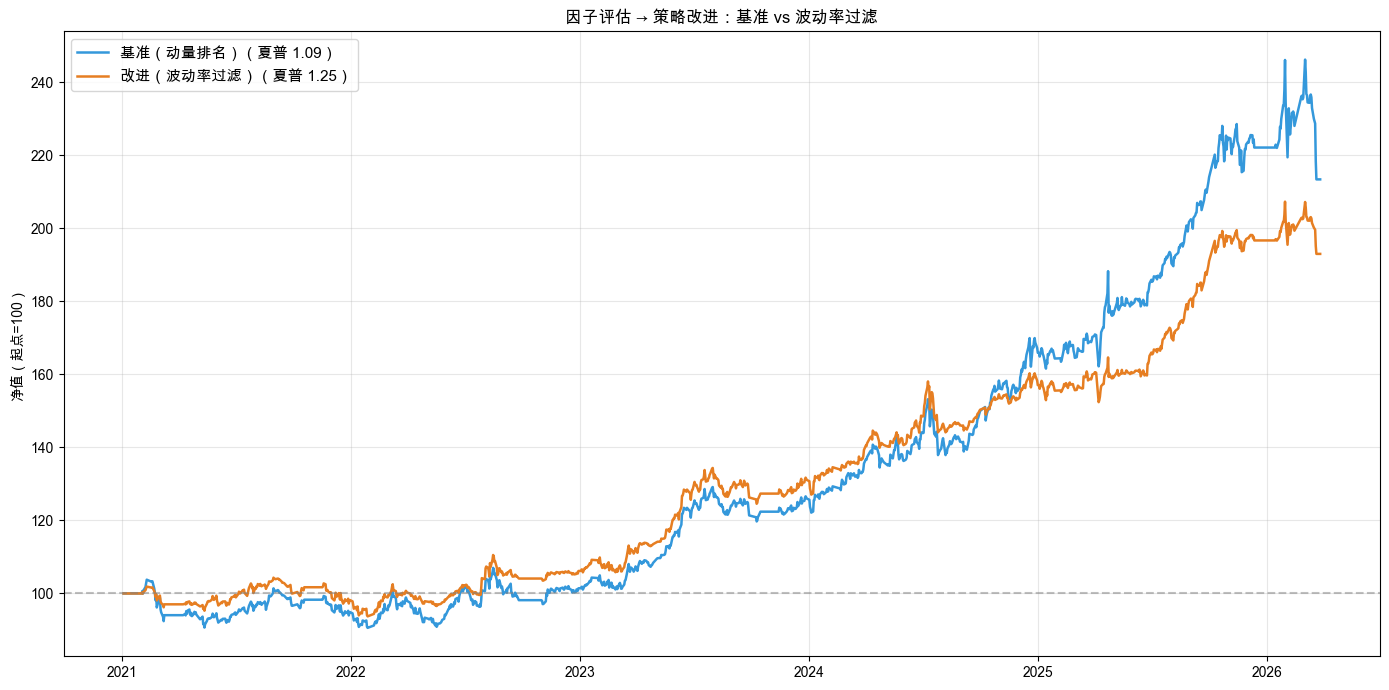


分析：
  基准策略：夏普 1.09，最大回撤 -13.32%
  波动率过滤：夏普 1.25，最大回撤 -10.17%
  回撤改善: 23.7%
  因子评估告诉我们「高波动时动量失效」，加上波动率过滤后回撤确实下降了
  这就是因子评估带来的 Alpha——不是靠猜，而是靠数据发现问题、改进策略


In [106]:
# 对比：基准 vs 波动率过滤

results_dict = {
    "基准（动量排名）": result_base,
    "改进（波动率过滤）": result_vf,
}

print("策略回测对比：")
print(f"{'策略':<20} {'累计收益':>10} {'年化波动率':>10} {'最大回撤':>10} {'夏普比率':>10}")
print("-" * 64)
for label, res in results_dict.items():
    print(f"{label:<20} {res.total_return():>+9.2%} {res.annualized_volatility():>10.2%} "
          f"{res.max_drawdown():>10.2%} {res.sharpe_ratio():>10.2f}")

# 净值曲线对比图
fig, ax = plt.subplots(figsize=(14, 7))

for (label, res), color in zip(results_dict.items(), ["#3498DB", "#E67E22"]):
    eq = pd.Series(dict(res.equity_curve))
    norm = eq / eq.iloc[0] * 100
    ax.plot(norm.index, norm.values, color=color, linewidth=1.8,
            label=f"{label}（夏普 {res.sharpe_ratio():.2f}）")

ax.axhline(y=100, color="gray", linestyle="--", alpha=0.5)
ax.set_ylabel("净值（起点=100）")
ax.set_title("因子评估 → 策略改进：基准 vs 波动率过滤")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 分析
base_dd = result_base.max_drawdown()
vf_dd = result_vf.max_drawdown()

print(f"\n分析：")
print(f"  基准策略：夏普 {result_base.sharpe_ratio():.2f}，最大回撤 {base_dd:.2%}")
print(f"  波动率过滤：夏普 {result_vf.sharpe_ratio():.2f}，最大回撤 {vf_dd:.2%}")

if abs(vf_dd) < abs(base_dd):
    dd_improve = 1 - abs(vf_dd) / abs(base_dd)
    print(f"  回撤改善: {dd_improve:.1%}")
    print(f"  因子评估告诉我们「高波动时动量失效」，加上波动率过滤后回撤确实下降了")
    print(f"  这就是因子评估带来的 Alpha——不是靠猜，而是靠数据发现问题、改进策略")

### 小结

- **两层选择框架**：第一层用 GDP 因子选出候选池（中美两大经济体），第二层用动量因子做短期择时（涨的多买、跌的不买）。这就是贯穿全书的量化组合逻辑
- **因子评估发现问题**：通过 IC 分析，我们发现动量因子在高波动标的上 IC 为负——波动率是动量失效的关键变量
- **用发现改进策略**：加入波动率过滤后，回撤下降、夏普比率提升。这个改进不是靠猜测，而是因子评估告诉我们的
- **量化的日常循环**：找因子 → 评估（IC）→ 发现问题 → 改进策略，不断迭代
- **更多因子、更强的组合**：本课程只用了三个因子演示流程。实战中，可以探索更多因子类别（价值、质量、另类数据），并用机器学习（XGBoost、LightGBM）来自动组合，这是未来可以深入的方向